In [ ]:
import sys
sys.path.append('..')

from src.flow_matching.probability_path import Sampleable, LinearConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver, LearnedVectorFieldODE
from src.flow_matching.models import MLPVectorField
from src.helpers import hist2d_samples, record_every

from matplotlib import pyplot as plt
import torch
import torch.distributions as D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

# Example from MIT Lab two

Modified example from the MIT course where isotropic Gaussian is transformed into an arbitrary distribution via a linear conditional probability path, comparing the ground-truth path and the path resulting from a learned vector field. 

In [3]:
class Gaussian(torch.nn.Module, Sampleable):
    """
    Multivariate Gaussian distribution
    """
    def __init__(self, mean: torch.Tensor, cov: torch.Tensor):
        """
        mean: shape (dim,)
        cov: shape (dim,dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples) -> torch.Tensor:
        return self.distribution.sample((num_samples,))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

    @classmethod
    def isotropic(cls, dim: int, std: float) -> "Gaussian":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std ** 2
        return cls(mean, cov)
    
class CheckerboardSampleable(Sampleable):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]

In [4]:
# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Gaussian.isotropic(dim=2, std=1.0),
    p_data = CheckerboardSampleable(device, grid_size=4)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=10000, device=device, lr=1e-3, batch_size=2000)

Training model with size: 0.049 MiB


Epoch 9999, loss: 8.339: : 10000it [03:00, 55.26it/s]


100%|██████████| 99/99 [00:04<00:00, 23.12it/s]


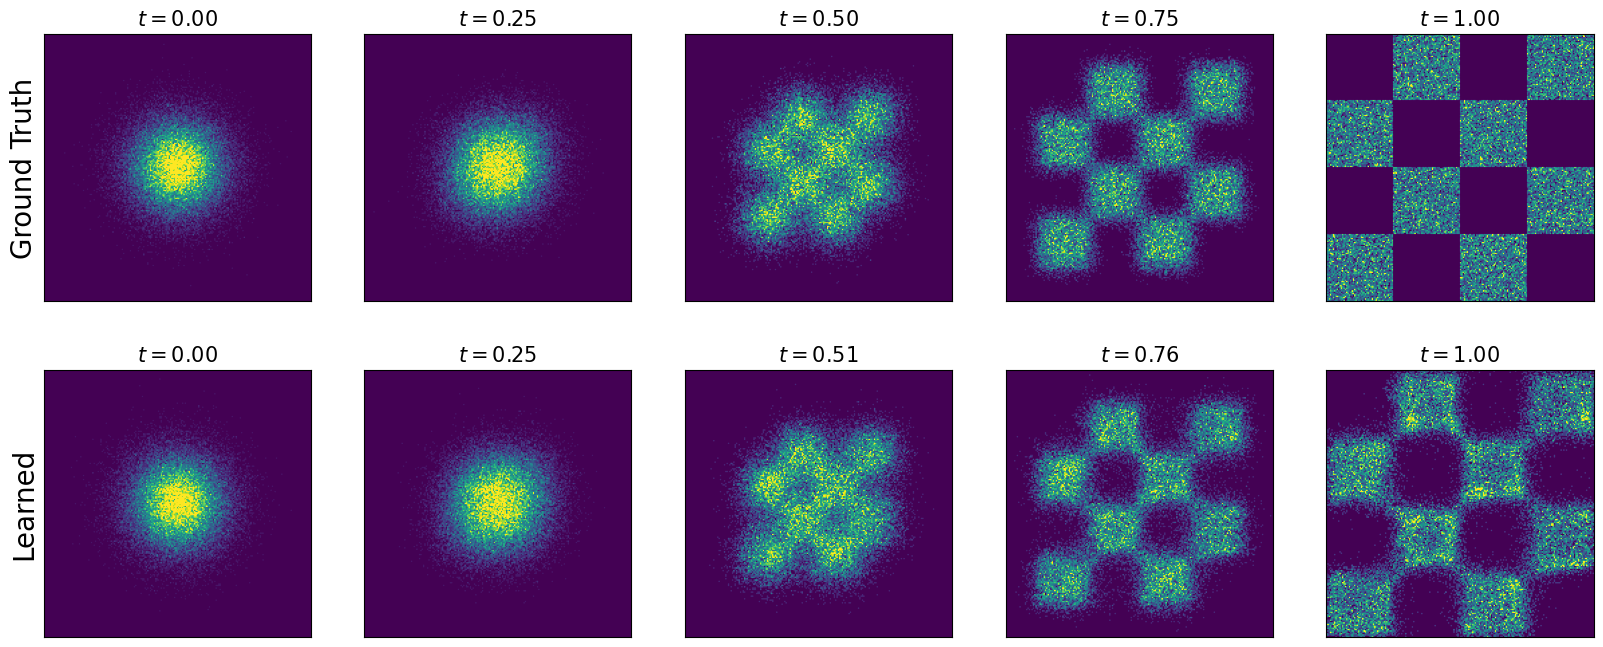

In [16]:
num_marginals = 5    # number of snapshots to plot
num_samples = 50000  # number of samples per snapshot 

plt.figure(figsize=(20,8))

# -------------------------------------------- #
#        Plotting Ground-Truth Marginals       #
# -------------------------------------------- #

ts = torch.linspace(0.0, 1.0, num_marginals).to(device)

for idx, t in enumerate(ts):

    tt = t.view(1,1).expand(num_samples, 1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts, range=[[-5, 5], [-5, 5]])

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={t.item():.2f}$', fontsize=15)

    plt.ylabel("Ground Truth", fontsize=20) if idx == 0 else None

# --------------------------------------------  #
#  Plotting Marginals of Learned Vector Field   #
# -------------------------------------------   #

# initialize ODE solver
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ODE from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# save only num_marginal snapshots of the trajectory
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

plot_idx = idx + 1

# plot the snapshots
for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]

    plt.subplot(2, num_marginals, plot_idx + idx + 1)
    hist2d_samples(xx, range=[[-5, 5], [-5, 5]])

    tt = ts[record_every_idxs[idx]]

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={tt.item():.2f}$', fontsize=15)
    plt.ylabel("Learned", fontsize=20) if idx == 0 else None

plt.show()